## 1. Cai Dat Dependencies

In [1]:
import torch;
print(torch.__version__);
print(torch.version.cuda);
print(torch.cuda.is_available());
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else "No GPU available"

2.10.0+cu128
12.8
True
NVIDIA GeForce RTX 3060


In [2]:
# Cài đặt các thư viện cần thiết
# %pip install torch torchvision transformers accelerate pillow einops timm gradio sentencepiece safetensors requests matplotlib

In [3]:
# Import các thư viện
import torch
import torch.nn as nn
from PIL import Image
from transformers import AutoModel, AutoImageProcessor, AutoTokenizer
from dataclasses import dataclass
from typing import Optional, List
import requests
from io import BytesIO

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

f:\anaconda3\envs\nckh\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.0 GB


---
## 1.5. Demo Dataset Structure

Xem cau truc du lieu truoc khi bat dau.

Total training samples: 2876

SAMPLE DATA STRUCTURE:

Sample keys: ['comment', 'list_img', 'text_label', 'text_img_label', 'label_each_img', 'text_one_img_label']

Comment: 💯 khách sạn kh có gì để chê 🤣

Image files: ['image_6670_0.png', 'image_6670_1.png']

Labels (text_img_label): ['Facilities#Positive', 'Public_area#Positive']

Image path: datasets\image\image_6670_0.png


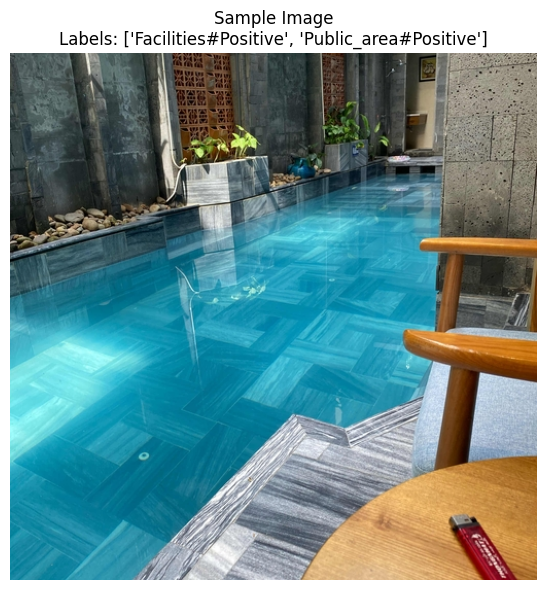


Image size: (512, 512)
Image mode: RGB

LABEL DISTRIBUTION:

Total labels: 8650
Unique labels: 18

Top 10 most common labels:
  Service#Positive                          1723 (19.9%)
  Public_area#Positive                      1509 (17.4%)
  Room#Positive                             1497 (17.3%)
  Location#Positive                          689 (8.0%)
  Facilities#Positive                        557 (6.4%)
  Public_area#Neutral                        519 (6.0%)
  Food#Positive                              444 (5.1%)
  Room#Neutral                               345 (4.0%)
  Room#Negative                              307 (3.5%)
  Facilities#Neutral                         208 (2.4%)


In [4]:
# ============================================
# DEMO DATASET STRUCTURE
# ============================================

import json
import os
from PIL import Image
import matplotlib.pyplot as plt

# Duong dan dataset
DATA_DIR = "datasets"
IMAGE_DIR = os.path.join(DATA_DIR, "image")

# Load 1 sample tu train.json
with open(os.path.join(DATA_DIR, "train.json"), 'r', encoding='utf-8') as f:
    train_data = json.load(f)

print(f"Total training samples: {len(train_data)}")
print("\n" + "=" * 80)
print("SAMPLE DATA STRUCTURE:")
print("=" * 80)

# Hien thi 1 sample
sample = train_data[0]
print(f"\nSample keys: {list(sample.keys())}")
print(f"\nComment: {sample.get('comment', 'N/A')}")
print(f"\nImage files: {sample.get('list_img', [])}")
print(f"\nLabels (text_img_label): {sample.get('text_img_label', [])}")

# Load va hien thi anh dau tien (neu co)
if sample.get('list_img') and len(sample['list_img']) > 0:
    img_path = os.path.join(IMAGE_DIR, sample['list_img'][0])
    if os.path.exists(img_path):
        print(f"\nImage path: {img_path}")
        
        # Hien thi anh
        img = Image.open(img_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Sample Image\nLabels: {sample.get('text_img_label', [])}")
        plt.tight_layout()
        plt.show()
        
        print(f"\nImage size: {img.size}")
        print(f"Image mode: {img.mode}")
    else:
        print(f"\n[WARNING] Image not found: {img_path}")

print("\n" + "=" * 80)
print("LABEL DISTRIBUTION:")
print("=" * 80)

# Dem phan bo labels
from collections import Counter
all_labels = []
for item in train_data:
    labels = item.get('text_img_label', [])
    all_labels.extend(labels)

label_counts = Counter(all_labels)
print(f"\nTotal labels: {len(all_labels)}")
print(f"Unique labels: {len(label_counts)}")
print(f"\nTop 10 most common labels:")
for label, count in label_counts.most_common(10):
    print(f"  {label:<40} {count:>5} ({count/len(all_labels)*100:.1f}%)")

---
## 2. Preprocessor và Swin Transformer V2 (Vision Encoder)

**Preprocessor**: Chuyen doi anh sang tensor, resize ve 256x256
**Swin Transformer V2**: Su dung hierarchical vision transformer voi shifted windows de xu ly anh hieu qua hon.

| Thong so | Gia tri |
|----------|--------|
| Model | `microsoft/swinv2-base-patch4-window8-256` |
| Input | 256x256 |
| Patch Size | 4x4 |
| Window Size | 8x8 |
| Hidden Dim | 1024 |
| Num Tokens | 64 (8x8 spatial features) |

In [5]:
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode

# ============================================
# PREPROCESSOR - Chuyen doi anh sang tensor
# ============================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size=256):
    """
    Preprocessor: Image -> Tensor
    
    Input: PIL Image (any size)
    Output: Tensor [3, input_size, input_size] normalized
    """
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

# ============================================
# SWIN TRANSFORMER V2 - Vision Encoder
# ============================================

class VisionEncoder(nn.Module):
    """
    Swin Transformer V2: Image -> Hierarchical features -> Img tokens
    
    Input: Tensor [B, 3, 256, 256]
    Output: Img tokens [B, 64, 1024]
    """
    
    def __init__(
        self, 
        model_name: str = "microsoft/swinv2-base-patch4-window8-256",
        device: str = "cuda",
        torch_dtype: torch.dtype = torch.float16
    ):
        super().__init__()
        self.device = device
        self.torch_dtype = torch_dtype
        
        print(f"Loading Swin Transformer V2: {model_name}")
        self.model = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch_dtype
        ).to(device)
        
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        
        # Freeze weights
        for param in self.model.parameters():
            param.requires_grad = False
        self.model.eval()
        
        # Swin Transformer V2 Base: hidden_size = 1024
        self.hidden_size = self.model.config.hidden_size  # 1024
        # Output spatial size for 256x256 input: 8x8 = 64 tokens
        self.num_patches = 64  # 8x8 spatial features at final stage
        
        print(f"Loaded: hidden_size={self.hidden_size}, num_patches={self.num_patches}")
    
    @torch.no_grad()
    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """
        Extract visual features using Swin Transformer V2.
        
        Input: [B, 3, 256, 256]
        Output: [B, 64, 1024] - Img tokens
        """
        pixel_values = pixel_values.to(self.device, dtype=self.torch_dtype)

        outputs = self.model(pixel_values=pixel_values)
        return outputs.last_hidden_state  # [B, 64, 1024]
        # Swin outputs: last_hidden_state shape [B, 64, 1024] for base model

---
## 3. Projection Layer (MLP)

Chuyen doi Img tokens tu Swin Transformer V2 (1024 dim) sang Lang tokens cho LLM (4096 dim).

```
Img tokens [B, 64, 1024] -> Linear(1024, 4096) -> GELU -> Linear(4096, 4096) -> Lang tokens [B, 64, 4096]
```

In [6]:
class MLPProjector(nn.Module):
    """
    Projection: Img tokens -> Lang tokens
    
    Input: [B, 64, 1024] tu Swin Transformer V2
    Output: [B, 64, 4096] cho LLM
    """
    
    def __init__(
        self,
        vision_dim: int = 1024,   # Swin Transformer V2 hidden dim
        llm_dim: int = 4096,      # LLM hidden dim
    ):
        super().__init__()
        
        self.projector = nn.Sequential(
            nn.Linear(vision_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim),
        )
        
        # Initialize weights
        for module in self.projector:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    def forward(self, img_tokens: torch.Tensor) -> torch.Tensor:
        """
        Project Img tokens to Lang tokens.
        
        Input: [B, 64, 1024]
        Output: [B, 64, 4096]
        """
        # Cast input to match projector weight dtype (float16 -> float32)
        img_tokens = img_tokens.to(dtype=self.projector[0].weight.dtype)
        return self.projector(img_tokens)

In [7]:
# ============================================
# KHOI TAO VISION ENCODER VA PROJECTOR
# ============================================

# Tao Vision Encoder - Swin Transformer V2
vision_encoder = VisionEncoder(
    model_name="microsoft/swinv2-base-patch4-window8-256",
    device=device,
    torch_dtype=torch.float16
)

# Tao Projection Layer - chuyen tu Swin features sang LLM space
# LLM dim se duoc cap nhat sau khi load model (InternVL3-8B = 3584)
projector = MLPProjector(
    vision_dim=1024,   # Swin V2 Base hidden dim
    llm_dim=3584,      # InternVL3-8B hidden dim (InternLM2 = 3584, NOT 4096)
).to(device)

print(f"  Vision hidden dim: {vision_encoder.hidden_size}")
print(f"  Vision num patches: {vision_encoder.num_patches}")
print(f"  Projector trainable params: {sum(p.numel() for p in projector.parameters()):,}")

Loading Swin Transformer V2: microsoft/swinv2-base-patch4-window8-256


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 471/471 [00:00<00:00, 977.21it/s, Materializing param=layernorm.weight]                                                                
Swinv2Model LOAD REPORT from: microsoft/swinv2-base-patch4-window8-256
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded: hidden_size=1024, num_patches=64
  Vision hidden dim: 1024
  Vision num patches: 64
  Projector trainable params: 16,522,240


---
## 4. LLM - InternVL3-8B-Instruct

LLM nhan:
- Lang tokens tu Projection (Image path)
- Lang tokens tu Embeddings (Text path)

Va output text qua de-Tokenizer.

| Model | Parameters | VRAM |
|-------|------------|------|
| InternVL3-1B | 1B | ~4GB |
| InternVL3-2B | 2B | ~6GB |
| InternVL3-8B-Instruct | 8B | ~18GB |

In [8]:
# ============================================
# SET HUGGING FACE CACHE TO F: DRIVE
# (Tranh download vao C:\Users\.cache\huggingface)
# ============================================
import os
os.environ["HF_HOME"] = r"F:\HuggingFaceCache"
print(f"HF_HOME set to: {os.environ['HF_HOME']}")

HF_HOME set to: F:\HuggingFaceCache


In [ ]:
# ============================================
# LOAD LLM - InternVL3-8B
# ============================================

import sys
import os
from pathlib import Path

MODEL_NAME = "OpenGVLab/InternLM3-8B-Instruct"

print(f"Loading {MODEL_NAME}...")
print("Lan dau se download ~16GB, vui long cho...")

# Determine dtype
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    torch_dtype = torch.bfloat16
else:
    torch_dtype = torch.float16

# Load tokenizer (Text -> word-pieces -> Embeddings -> Lang tokens)
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

# ============================================
# FIX 1: Patch cached InternVL3 code - meta tensor .item() error
# Search ALL possible cache locations
# ============================================
old_pattern = "[x.item() for x in torch.linspace(0, config.drop_path_rate, config.num_hidden_layers)]"
new_pattern = "torch.linspace(0, config.drop_path_rate, config.num_hidden_layers, device='cpu').tolist()"

# Collect all possible cache directories
cache_dirs = []
# Default HF cache
cache_dirs.append(Path.home() / ".cache" / "huggingface" / "modules" / "transformers_modules")
# HF_HOME based cache
hf_home = os.environ.get("HF_HOME")
if hf_home:
    cache_dirs.append(Path(hf_home) / "modules" / "transformers_modules")
# TRANSFORMERS_CACHE based
tf_cache = os.environ.get("TRANSFORMERS_CACHE")
if tf_cache:
    cache_dirs.append(Path(tf_cache) / "modules" / "transformers_modules")

patched_count = 0
for cache_base in cache_dirs:
    if not cache_base.exists():
        print(f"[FIX 1] Cache dir not found (skip): {cache_base}")
        continue
    print(f"[FIX 1] Searching: {cache_base}")
    for vit_file in cache_base.rglob("modeling_intern_vit.py"):
        try:
            content = vit_file.read_text(encoding='utf-8')
            if old_pattern in content:
                content = content.replace(old_pattern, new_pattern)
                vit_file.write_text(content, encoding='utf-8')
                print(f"[FIX 1] Patched: {vit_file}")
                patched_count += 1
            else:
                print(f"[FIX 1] Already patched or different pattern: {vit_file}")
        except Exception as e:
            print(f"[FIX 1] Error patching {vit_file}: {e}")

if patched_count > 0:
    # Clear ALL cached InternVL modules to force reimport from patched files
    keys_to_remove = [k for k in sys.modules if 'intern' in k.lower()]
    for k in keys_to_remove:
        del sys.modules[k]
    print(f"[FIX 1] Cleared {len(keys_to_remove)} cached modules")
else:
    print("[FIX 1] No files needed patching")

# ============================================
# FIX 2: Patch transformers compatibility - missing all_tied_weights_keys
# ============================================
from transformers import PreTrainedModel
if hasattr(PreTrainedModel, 'mark_tied_weights_as_initialized'):
    _orig_mark = PreTrainedModel.mark_tied_weights_as_initialized
    def _patched_mark(self):
        if not hasattr(self, 'all_tied_weights_keys'):
            self.all_tied_weights_keys = {}
        return _orig_mark(self)
    PreTrainedModel.mark_tied_weights_as_initialized = _patched_mark
    print("[FIX 2] Patched all_tied_weights_keys compatibility")

# ============================================
# Load model (LLM + de-Tokenizer)
# ============================================
model = AutoModel.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    trust_remote_code=True,
).to(device).eval()

print("Model loaded!")

Loading OpenGVLab/InternVL3-8B-Instruct...
Lan dau se download ~16GB, vui long cho...


Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


[FIX 1] Searching: C:\Users\httua\.cache\huggingface\modules\transformers_modules
[FIX 1] Already patched or different pattern: C:\Users\httua\.cache\huggingface\modules\transformers_modules\OpenGVLab\InternVL3_hyphen_8B_hyphen_Instruct\ddb3a169d5582e5c76e0809a128e55ab63686ada\modeling_intern_vit.py
[FIX 1] Cache dir not found (skip): F:\HuggingFaceCache\modules\transformers_modules
[FIX 1] No files needed patching
[FIX 2] Patched all_tied_weights_keys compatibility


Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


FlashAttention2 is not installed.


Loading weights: 100%|██████████| 685/685 [00:00<00:00, 1033.12it/s, Materializing param=vision_model.encoder.layers.23.norm2.weight]                  


Model loaded!


---
## 5. Dataset va DataLoader

In [10]:
import json
import os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ============================================
# LABEL DEFINITIONS - Chi co 3 Sentiments
# ============================================

SENTIMENT_LABELS = ["Positive", "Negative", "Neutral"]

# Tao mapping label -> id
LABEL2ID = {label: idx for idx, label in enumerate(SENTIMENT_LABELS)}
ID2LABEL = {idx: label for idx, label in enumerate(SENTIMENT_LABELS)}
NUM_LABELS = len(LABEL2ID)

print(f"Number of labels: {NUM_LABELS}")
print(f"Labels: {list(LABEL2ID.keys())}")

Number of labels: 3
Labels: ['Positive', 'Negative', 'Neutral']


In [11]:
# ============================================
# DATA LOADER - Doc train/dev/test.json
# ============================================

def load_dataset_json(json_path: str) -> list:
    """
    Doc file JSON dataset.
    
    Args:
        json_path: Duong dan toi file JSON
        
    Returns:
        List cac samples
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Loaded {len(data)} samples from {json_path}")
    return data


def load_all_splits(data_dir: str = "datasets"):
    """
    Load tat ca cac split: train, dev, test.
    
    Args:
        data_dir: Thu muc chua data
        
    Returns:
        Dict chua train, dev, test data
    """
    splits = {}
    for split in ["train", "dev", "test"]:
        json_path = os.path.join(data_dir, f"{split}.json")
        if os.path.exists(json_path):
            splits[split] = load_dataset_json(json_path)
        else:
            print(f"[WARNING] {json_path} not found!")
            splits[split] = []
    return splits


# Load data
DATA_DIR = "datasets"
IMAGE_DIR = os.path.join(DATA_DIR, "image")

dataset_splits = load_all_splits(DATA_DIR)

print(f"\nDataset Statistics:")
print(f"  Train: {len(dataset_splits['train'])} samples")
print(f"  Dev:   {len(dataset_splits['dev'])} samples")
print(f"  Test:  {len(dataset_splits['test'])} samples")

Loaded 2876 samples from datasets\train.json
Loaded 1000 samples from datasets\dev.json
Loaded 1000 samples from datasets\test.json

Dataset Statistics:
  Train: 2876 samples
  Dev:   1000 samples
  Test:  1000 samples


In [12]:
# ============================================
# PYTORCH DATASET CLASS
# ============================================

class SentimentDataset(Dataset):
    """
    PyTorch Dataset cho Sentiment Analysis.
    
    Moi sample gom:
    - comment: Text binh luan
    - list_img: Danh sach ten file anh
    - labels: Sentiment labels (Positive/Negative/Neutral)
    """
    
    def __init__(
        self,
        data: list,
        image_dir: str,
        label2id: dict,
        transform=None,
    ):
        self.data = data
        self.image_dir = image_dir
        self.label2id = label2id
        self.num_labels = len(label2id)
        self.transform = transform if transform else build_transform(256)
        
        self.samples = self._prepare_samples()
        print(f"Prepared {len(self.samples)} valid samples")
    
    def _extract_sentiment(self, label: str) -> str:
        """Extract sentiment tu label goc (VD: 'Room#Positive' -> 'Positive')."""
        if "#" in label:
            return label.split("#")[1]
        return label
    
    def _prepare_samples(self) -> list:
        """Loc va chuan bi samples hop le."""
        valid_samples = []
        
        for item in self.data:
            if not item.get("list_img") or len(item["list_img"]) == 0:
                continue
            
            raw_labels = item.get("text_img_label", [])
            if not raw_labels:
                continue
            
            # Extract sentiments tu labels goc
            sentiments = set()
            for label in raw_labels:
                sentiment = self._extract_sentiment(label)
                if sentiment in self.label2id:
                    sentiments.add(sentiment)
            
            if not sentiments:
                continue
            
            img_name = item["list_img"][0]
            img_path = os.path.join(self.image_dir, img_name)
            if not os.path.exists(img_path):
                continue
            
            valid_samples.append({
                "comment": item.get("comment", ""),
                "image_path": img_path,
                "labels": list(sentiments),
            })
        
        return valid_samples
    
    def __len__(self):
        return len(self.samples)
    
    def _labels_to_tensor(self, labels: list) -> torch.Tensor:
        """Convert list labels thanh multi-hot tensor."""
        label_tensor = torch.zeros(self.num_labels)
        for label in labels:
            if label in self.label2id:
                label_tensor[self.label2id[label]] = 1.0
        return label_tensor
    
    def __getitem__(self, idx: int) -> dict:
        sample = self.samples[idx]
        
        # Load image
        image = Image.open(sample["image_path"]).convert("RGB")
        
        # Preprocessor: Image -> Tensor
        pixel_values = self.transform(image)
        
        # Convert labels to tensor
        label_tensor = self._labels_to_tensor(sample["labels"])
        
        return {
            "pixel_values": pixel_values,
            "labels": label_tensor,
            "comment": sample["comment"],
            "image_path": sample["image_path"],
        }


def collate_fn(batch):
    """
    Custom collate function cho DataLoader.
    
    Text path: Text -> Tokenizer -> word-pieces (input_ids)
    """
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    comments = [item["comment"] for item in batch]
    image_paths = [item["image_path"] for item in batch]
    
    # Tokenizer: Text -> word-pieces (input_ids, attention_mask)
    text_inputs = tokenizer(
        comments,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    
    return {
        "pixel_values": pixel_values,
        "input_ids": text_inputs.input_ids,           # word-pieces
        "attention_mask": text_inputs.attention_mask,
        "labels": labels,
        "comments": comments,
        "image_paths": image_paths,
    }

In [13]:
# ============================================
# TAO DATALOADERS
# ============================================

# Tao datasets
train_dataset = SentimentDataset(
    data=dataset_splits["train"],
    image_dir=IMAGE_DIR,
    label2id=LABEL2ID,
)

dev_dataset = SentimentDataset(
    data=dataset_splits["dev"],
    image_dir=IMAGE_DIR,
    label2id=LABEL2ID,
)

test_dataset = SentimentDataset(
    data=dataset_splits["test"],
    image_dir=IMAGE_DIR,
    label2id=LABEL2ID,
)

# Tao dataloaders
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

print(f"\nDataLoader Statistics:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Dev batches:   {len(dev_loader)}")
print(f"  Test batches:  {len(test_loader)}")

# Test 1 batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  pixel_values shape: {sample_batch['pixel_values'].shape}")
print(f"  labels shape: {sample_batch['labels'].shape}")

Prepared 2876 valid samples
Prepared 1000 valid samples
Prepared 1000 valid samples

DataLoader Statistics:
  Train batches: 719
  Dev batches:   250
  Test batches:  250

Sample batch:
  pixel_values shape: torch.Size([4, 3, 256, 256])
  labels shape: torch.Size([4, 3])


---
## 6. Training Loop

Fine-tune Projection Layer, giu nguyen (freeze) Swin Transformer V2.

In [14]:
# ============================================
# MULTIMODAL SENTIMENT MODEL
# ============================================
# Architecture theo diagram:
# Image -> Preprocessor -> Swin V2 -> Projection ──┐
#                                                  ├──> LLM -> Classifier -> Logits [B, 3]
# Text  -> Tokenizer -> Embeddings ────────────────┘

class MultimodalSentimentModel(nn.Module):
    """
    Model phan loai sentiment theo kien truc VLM.
    
    Training mode (forward):
      [Img Lang tokens; Text Lang tokens] -> LLM hidden states -> Classifier -> Logits [B, 3]
    
    Inference mode (generate_text):
      [Img Lang tokens; Text Lang tokens] -> LLM generate -> de-Tokenizer -> Output Text
    """
    
    def __init__(
        self,
        vision_encoder: VisionEncoder,
        projector: MLPProjector,
        llm_model,
        tokenizer,
        num_labels: int = 3,
    ):
        super().__init__()
        
        self.vision_encoder = vision_encoder
        self.projector = projector
        self.llm = llm_model
        self.tokenizer = tokenizer
        
        # Detect LLM dtype and hidden size
        self.llm_dtype = next(llm_model.language_model.parameters()).dtype
        self.llm_hidden_size = llm_model.language_model.config.hidden_size  # 3584
        print(f"  LLM dtype: {self.llm_dtype}")
        print(f"  LLM hidden_size: {self.llm_hidden_size}")
        
        # Text Embeddings layer tu LLM (frozen)
        self.text_embeddings = llm_model.language_model.get_input_embeddings()
        for param in self.text_embeddings.parameters():
            param.requires_grad = False
        
        # Freeze vision encoder
        for param in self.vision_encoder.parameters():
            param.requires_grad = False
        
        # Freeze LLM
        for param in self.llm.parameters():
            param.requires_grad = False
        
        # ============================================
        # CLASSIFIER HEAD (trainable)
        # LLM hidden states -> Logits [B, num_labels]
        # ============================================
        self.classifier = nn.Sequential(
            nn.Linear(self.llm_hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels),
        )
        # Initialize classifier
        for module in self.classifier:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
        
        print(f"  Classifier: {self.llm_hidden_size} -> 256 -> {num_labels}")
    
    def _get_combined_embeds(self, pixel_values, input_ids, attention_mask):
        """
        Shared logic: build combined embeddings from image + text.
        
        Returns: combined_embeds, full_attention_mask
        """
        # IMAGE PATH: Image -> Swin V2 -> Projection -> Img Lang tokens
        with torch.no_grad():
            img_tokens = self.vision_encoder(pixel_values)  # [B, 64, 1024]
        
        img_lang_tokens = self.projector(img_tokens)  # [B, 64, 3584]
        
        # TEXT PATH: word-pieces -> Embeddings -> Text Lang tokens
        with torch.no_grad():
            text_lang_tokens = self.text_embeddings(input_ids.to(img_lang_tokens.device))
        
        # Cast to LLM dtype
        img_lang_tokens = img_lang_tokens.to(dtype=self.llm_dtype)
        text_lang_tokens = text_lang_tokens.to(dtype=self.llm_dtype)
        
        # Concatenate
        combined_embeds = torch.cat([img_lang_tokens, text_lang_tokens], dim=1)
        
        # Attention mask
        batch_size = img_lang_tokens.size(0)
        img_mask = torch.ones(batch_size, img_lang_tokens.size(1), device=img_lang_tokens.device)
        if attention_mask is not None:
            full_attention_mask = torch.cat([img_mask, attention_mask.to(img_lang_tokens.device)], dim=1)
        else:
            full_attention_mask = torch.ones(batch_size, combined_embeds.size(1), device=img_lang_tokens.device)
        
        return combined_embeds, full_attention_mask
    
    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Classification forward pass.
        
        Returns: logits [B, num_labels]
        """
        combined_embeds, full_attention_mask = self._get_combined_embeds(
            pixel_values, input_ids, attention_mask
        )
        
        # LLM forward -> get hidden states
        # CausalLM returns CausalLMOutputWithPast (has .logits, .hidden_states)
        # We need output_hidden_states=True to get the last hidden layer
        with torch.no_grad():
            outputs = self.llm.language_model(
                inputs_embeds=combined_embeds,
                attention_mask=full_attention_mask,
                output_hidden_states=True,
            )
            # outputs.hidden_states is a tuple: (embed_output, layer1, layer2, ..., layerN)
            # Last element = final layer hidden states [B, seq_len, 3584]
            hidden_states = outputs.hidden_states[-1]
        
        # Mean pooling over sequence (weighted by attention mask)
        mask = full_attention_mask.unsqueeze(-1).to(hidden_states.dtype)  # [B, seq_len, 1]
        pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1)  # [B, 3584]
        
        # Classifier: [B, 3584] -> [B, num_labels]
        logits = self.classifier(pooled.float())  # float32 for stable training
        
        return logits
    
    def generate_text(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        max_new_tokens: int = 128,
    ) -> list:
        """
        Text generation for inference.
        
        Returns: List of generated text strings
        """
        combined_embeds, full_attention_mask = self._get_combined_embeds(
            pixel_values, input_ids, attention_mask
        )
        
        with torch.no_grad():
            output_ids = self.llm.language_model.generate(
                inputs_embeds=combined_embeds,
                attention_mask=full_attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
            )
        
        return self.tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    
    def get_trainable_params(self):
        """Tra ve so luong trainable parameters."""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable


# Tao model
sentiment_model = MultimodalSentimentModel(
    vision_encoder=vision_encoder,
    projector=projector,
    llm_model=model,
    tokenizer=tokenizer,
    num_labels=NUM_LABELS,
).to(device)

total_params, trainable_params = sentiment_model.get_trainable_params()
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

  LLM dtype: torch.bfloat16
  LLM hidden_size: 3584
  Classifier: 3584 -> 256 -> 3
Total parameters: 8,048,708,347
Trainable parameters: 17,440,771
Frozen parameters: 8,031,267,576


In [15]:
# ============================================
# TRAINING CONFIGURATION
# ============================================

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Hyperparameters
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 10

# Optimizer - chi train projection layer va classifier
trainable_params_list = [p for p in sentiment_model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params_list, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps)

# Loss function - Multi-label classification
criterion = nn.BCEWithLogitsLoss()

print(f"Training Configuration:")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Total Steps: {total_steps}")

Training Configuration:
  Learning Rate: 0.0001
  Weight Decay: 0.01
  Epochs: 10
  Total Steps: 7190


In [16]:
# ============================================
# TRAINING LOOP
# ============================================

def train_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    """Train 1 epoch."""
    model.train()
    total_loss = 0
    num_batches = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for batch in progress_bar:
        # Image input
        pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
        # Text input (tokenized)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        # Labels
        labels = batch["labels"].to(device)
        
        optimizer.zero_grad()
        
        # Forward: Image + Text -> Logits
        logits = model(pixel_values, input_ids, attention_mask)
        
        loss = criterion(logits.float(), labels.float())
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        num_batches += 1
        
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})
    
    avg_loss = total_loss / num_batches
    return avg_loss


@torch.no_grad()
def validate(model, dataloader, criterion, device):
    """Validate model."""
    model.eval()
    total_loss = 0
    num_batches = 0
    
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="Validating"):
        # Image input
        pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
        # Text input (tokenized)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        # Labels
        labels = batch["labels"].to(device)
        
        # Forward: Image + Text -> Logits
        logits = model(pixel_values, input_ids, attention_mask)
        loss = criterion(logits.float(), labels.float())
        
        total_loss += loss.item()
        num_batches += 1
        
        preds = torch.sigmoid(logits) > 0.5
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    
    avg_loss = total_loss / num_batches
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    return avg_loss, all_preds, all_labels

In [17]:
# ============================================
# RUN TRAINING
# ============================================

best_val_loss = float('inf')
train_losses = []
val_losses = []

print("Starting Training...")
print("=" * 50)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    
    train_loss = train_epoch(
        sentiment_model, train_loader, optimizer, scheduler, criterion, device
    )
    train_losses.append(train_loss)
    
    val_loss, val_preds, val_labels = validate(
        sentiment_model, dev_loader, criterion, device
    )
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Only save TRAINABLE parameters (projector + classifier)
        # Saving the full model (~16GB LLM) causes MemoryError
        from safetensors.torch import save_file
        trainable_state = {
            k: v.cpu() for k, v in sentiment_model.state_dict().items()
            if any(k.startswith(prefix) for prefix in ['projector.', 'classifier.'])
        }
        save_file(trainable_state, 'best_model.safetensors')
        # Lưu thêm training info
        torch.save({
            'epoch': epoch,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, 'training_info.pt', _use_new_zipfile_serialization=True)
        print(f"[SAVED] Best model saved! ({len(trainable_state)} tensors)")

print("\n" + "=" * 50)
print("Training Complete!")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Starting Training...

Epoch 1/10
------------------------------


Validating: 100%|██████████| 250/250 [41:44<00:00, 10.02s/it]


Train Loss: 0.5430
Val Loss:   0.3954
[SAVED] Best model saved! (8 tensors)

Epoch 2/10
------------------------------


Validating: 100%|██████████| 250/250 [40:53<00:00,  9.82s/it]


Train Loss: 0.3836
Val Loss:   0.4003

Epoch 3/10
------------------------------


...

Train Loss: 0.2419
Val Loss:   0.3473
[SAVED] Best model saved! (8 tensors)

Epoch 9/10
------------------------------


Validating: 100%|██████████| 250/250 [40:02<00:00,  9.61s/it]


Train Loss: 0.2349
Val Loss:   0.3492

Epoch 10/10
------------------------------


Validating: 100%|██████████| 250/250 [39:30<00:00,  9.48s/it]

Train Loss: 0.2285
Val Loss:   0.3494

Training Complete!
Best Validation Loss: 0.3473


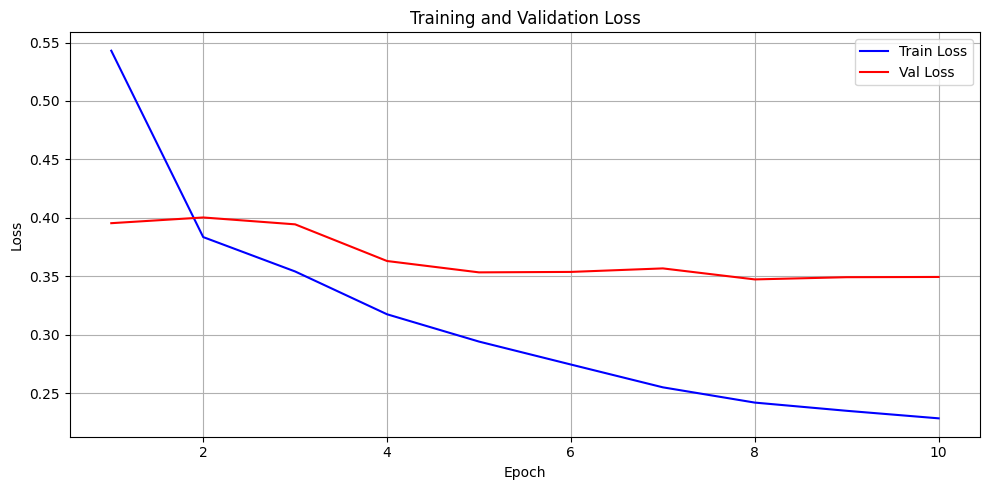

In [18]:
# ============================================
# PLOT TRAINING CURVES
# ============================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, 'b-', label='Train Loss')
ax.plot(epochs_range, val_losses, 'r-', label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [20]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------------------- -- 7.6/8.1 MB 47.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 33.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.4 MB ? eta -:--:--
   ------------------ --------------------- 16.8/36.4 MB 87.8 MB/s eta 0:00:01
   ---------------------------- ----------- 26.0/36.4 MB 63.3 MB/s eta 0:00:01
   -------------------------------- ------- 29.6/36.4 MB 48.2 MB/s eta 0:00:01
   ----------------------------------- ---- 32.2/36.4 MB 40.1 MB/s eta 0:00:01
   -------------------------------------- - 35.1/36.4 MB 34.3 MB/s eta 0:00:01
   ---------------------------------------- 36.4/36.4 MB 31.7 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   -----

---
## 7. Evaluation (Accuracy, Precision, Recall, F1)

In [21]:
# ============================================
# EVALUATION METRICS
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    hamming_loss,
)
import numpy as np


def compute_metrics(preds: torch.Tensor, labels: torch.Tensor, id2label: dict) -> dict:
    """
    Tinh cac metrics cho multi-label classification.
    
    Args:
        preds: Predictions tensor [N, num_labels]
        labels: Ground truth tensor [N, num_labels]
        id2label: Mapping id -> label name
        
    Returns:
        Dict chua cac metrics
    """
    preds_np = preds.numpy()
    labels_np = labels.numpy()
    
    # Overall metrics (micro, macro, weighted)
    metrics = {
        # Micro metrics - tinh tren tat ca predictions
        "micro_precision": precision_score(labels_np, preds_np, average='micro', zero_division=0),
        "micro_recall": recall_score(labels_np, preds_np, average='micro', zero_division=0),
        "micro_f1": f1_score(labels_np, preds_np, average='micro', zero_division=0),
        
        # Macro metrics - trung binh cua tung class
        "macro_precision": precision_score(labels_np, preds_np, average='macro', zero_division=0),
        "macro_recall": recall_score(labels_np, preds_np, average='macro', zero_division=0),
        "macro_f1": f1_score(labels_np, preds_np, average='macro', zero_division=0),
        
        # Weighted metrics
        "weighted_precision": precision_score(labels_np, preds_np, average='weighted', zero_division=0),
        "weighted_recall": recall_score(labels_np, preds_np, average='weighted', zero_division=0),
        "weighted_f1": f1_score(labels_np, preds_np, average='weighted', zero_division=0),
        
        # Samples metrics
        "samples_f1": f1_score(labels_np, preds_np, average='samples', zero_division=0),
        
        # Hamming loss
        "hamming_loss": hamming_loss(labels_np, preds_np),
        
        # Exact match ratio
        "exact_match_ratio": np.mean(np.all(preds_np == labels_np, axis=1)),
    }
    
    return metrics


def print_metrics(metrics: dict):
    """In metrics dep."""
    print("\n" + "=" * 60)
    print("EVALUATION RESULTS")
    print("=" * 60)
    
    print("\n[MICRO METRICS] (tren tat ca predictions)")
    print(f"  Precision: {metrics['micro_precision']:.4f}")
    print(f"  Recall:    {metrics['micro_recall']:.4f}")
    print(f"  F1-Score:  {metrics['micro_f1']:.4f}")
    
    print("\n[MACRO METRICS] (trung binh cua tung class)")
    print(f"  Precision: {metrics['macro_precision']:.4f}")
    print(f"  Recall:    {metrics['macro_recall']:.4f}")
    print(f"  F1-Score:  {metrics['macro_f1']:.4f}")
    
    print("\n[WEIGHTED METRICS]")
    print(f"  Precision: {metrics['weighted_precision']:.4f}")
    print(f"  Recall:    {metrics['weighted_recall']:.4f}")
    print(f"  F1-Score:  {metrics['weighted_f1']:.4f}")
    
    print("\n[OTHER METRICS]")
    print(f"  Samples F1:        {metrics['samples_f1']:.4f}")
    print(f"  Hamming Loss:      {metrics['hamming_loss']:.4f}")
    print(f"  Exact Match Ratio: {metrics['exact_match_ratio']:.4f}")
    
    print("=" * 60)

In [26]:
# ============================================
# EVALUATE ON TEST SET
# ============================================

# Load best model (only trainable weights: projector + classifier)
from safetensors.torch import load_file
import os

if os.path.exists('best_model.safetensors'):
    trainable_state = load_file('best_model.safetensors')
    # Move to correct device and load into model
    trainable_state = {k: v.to(device) for k, v in trainable_state.items()}
    sentiment_model.load_state_dict(trainable_state, strict=False)
    # Load training info
    if os.path.exists('training_info.pt'):
        info = torch.load('training_info.pt', weights_only=True)
        print(f"Loaded best model from epoch {info['epoch'] + 1}")
    else:
        print("Loaded best model")
elif os.path.exists('best_model.pt'):
    # Fallback: Load từ old format
    checkpoint = torch.load('best_model.pt', weights_only=False)
    sentiment_model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    print(f"Loaded best model from epoch {checkpoint['epoch'] + 1}")
else:
    print("[WARNING] No saved model found!")

# Evaluate on test set
test_loss, test_preds, test_labels = validate(
    sentiment_model, test_loader, criterion, device
)

print(f"\nTest Loss: {test_loss:.4f}")

# Compute metrics
test_metrics = compute_metrics(test_preds, test_labels, ID2LABEL)
print_metrics(test_metrics)

Loaded best model from epoch 8


Validating: 100%|██████████| 250/250 [41:27<00:00,  9.95s/it]


Test Loss: 0.3618

EVALUATION RESULTS

[MICRO METRICS] (tren tat ca predictions)
  Precision: 0.8473
  Recall:    0.8141
  F1-Score:  0.8304

[MACRO METRICS] (trung binh cua tung class)
  Precision: 0.7730
  Recall:    0.7075
  F1-Score:  0.7364

[WEIGHTED METRICS]
  Precision: 0.8345
  Recall:    0.8141
  F1-Score:  0.8221

[OTHER METRICS]
  Samples F1:        0.8525
  Hamming Loss:      0.1587
  Exact Match Ratio: 0.6190


In [27]:
# ============================================
# PER-CLASS METRICS
# ============================================

def compute_per_class_metrics(preds: torch.Tensor, labels: torch.Tensor, id2label: dict):
    """Tinh metrics cho tung class."""
    preds_np = preds.numpy()
    labels_np = labels.numpy()
    
    print("\n" + "=" * 80)
    print("PER-CLASS METRICS")
    print("=" * 80)
    print(f"{'Label':<30} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 80)
    
    results = []
    for idx in range(preds_np.shape[1]):
        label_name = id2label[idx]
        y_true = labels_np[:, idx]
        y_pred = preds_np[:, idx]
        
        support = int(y_true.sum())
        if support == 0:
            precision = recall = f1 = 0.0
        else:
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
        
        results.append({
            'label': label_name,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support,
        })
        
        print(f"{label_name:<30} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {support:>10}")
    
    print("=" * 80)
    return results


# Compute per-class metrics
per_class_results = compute_per_class_metrics(test_preds, test_labels, ID2LABEL)


PER-CLASS METRICS
Label                           Precision     Recall         F1    Support
--------------------------------------------------------------------------------
Positive                           0.9382     0.9759     0.9567        871
Negative                           0.7574     0.6154     0.6790        208
Neutral                            0.6233     0.5312     0.5736        352


---
## 8. Inference voi Trained Pipeline

Su dung trained pipeline: Image -> Preprocessor -> Swin V2 -> Projection -> LLM -> Classifier -> Sentiment

**Luu y**: KHONG dung `model.chat()` vi no su dung ViT rieng cua InternVL3, khong phai Swin V2 + Projector da fine-tune.

In [28]:
# ============================================
# INFERENCE FUNCTION
# ============================================
# Su dung trained pipeline: Image -> Swin V2 -> Projection -> LLM -> Classifier -> Sentiment
# KHONG dung model.chat() vi no dung ViT rieng cua InternVL3, khong phai Swin V2 + Projector da train

def predict_sentiment(
    image_path: str,
    comment: str,
    model: MultimodalSentimentModel = sentiment_model,
    threshold: float = 0.5,
) -> dict:
    """
    Phan tich sentiment su dung trained pipeline.
    
    Pipeline: 
      Image -> Preprocessor -> Swin V2 -> Projection ──┐
                                                       ├──> LLM -> Classifier -> Logits -> Sentiment
      Text  -> Tokenizer -> Embeddings ────────────────┘
    
    Args:
        image_path: Duong dan toi anh
        comment: Text binh luan
        model: MultimodalSentimentModel da train
        threshold: Nguong sigmoid cho multi-label (default 0.5)
    
    Returns:
        Dict chua predictions va probabilities
    """
    model.eval()
    
    # IMAGE PATH: Image -> Preprocessor -> Tensor
    transform = build_transform(input_size=256)
    image = Image.open(image_path).convert("RGB")
    pixel_values = transform(image).unsqueeze(0)  # [1, 3, 256, 256]
    pixel_values = pixel_values.to(device, dtype=torch.float16)
    
    # TEXT PATH: Text -> Tokenizer -> word-pieces
    text_inputs = tokenizer(
        [comment],
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    attention_mask = text_inputs.attention_mask.to(device)
    
    # Forward: Swin V2 -> Projection + Embeddings -> LLM -> Classifier -> Logits
    with torch.no_grad():
        logits = model(pixel_values, input_ids, attention_mask)  # [1, 3]
        probs = torch.sigmoid(logits).squeeze(0).cpu()           # [3]
        preds = (probs > threshold).int()
    
    # Map to labels
    results = {
        "predictions": {},
        "predicted_labels": [],
    }
    for idx, label in ID2LABEL.items():
        prob = probs[idx].item()
        predicted = preds[idx].item() == 1
        results["predictions"][label] = {
            "probability": prob,
            "predicted": predicted,
        }
        if predicted:
            results["predicted_labels"].append(label)
    
    # Fallback: neu khong co label nao > threshold, lay label co prob cao nhat
    if not results["predicted_labels"]:
        best_idx = probs.argmax().item()
        results["predicted_labels"].append(ID2LABEL[best_idx])
        results["predictions"][ID2LABEL[best_idx]]["predicted"] = True
    
    return results


def predict_sentiment_batch(
    image_paths: list,
    comments: list,
    model: MultimodalSentimentModel = sentiment_model,
    threshold: float = 0.5,
) -> list:
    """
    Predict sentiment cho nhieu samples cung luc.
    """
    model.eval()
    transform = build_transform(input_size=256)
    
    # Load + transform tat ca anh
    pixel_list = []
    for img_path in image_paths:
        image = Image.open(img_path).convert("RGB")
        pixel_list.append(transform(image))
    pixel_values = torch.stack(pixel_list).to(device, dtype=torch.float16)
    
    # Tokenize tat ca comments
    text_inputs = tokenizer(
        comments,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    attention_mask = text_inputs.attention_mask.to(device)
    
    # Forward
    with torch.no_grad():
        logits = model(pixel_values, input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu()
        preds = (probs > threshold).int()
    
    results = []
    for i in range(len(image_paths)):
        sample_result = {"predictions": {}, "predicted_labels": []}
        for idx, label in ID2LABEL.items():
            prob = probs[i][idx].item()
            predicted = preds[i][idx].item() == 1
            sample_result["predictions"][label] = {
                "probability": prob,
                "predicted": predicted,
            }
            if predicted:
                sample_result["predicted_labels"].append(label)
        if not sample_result["predicted_labels"]:
            best_idx = probs[i].argmax().item()
            sample_result["predicted_labels"].append(ID2LABEL[best_idx])
        results.append(sample_result)
    
    return results

In [ ]:
# ============================================
# DEMO INFERENCE - Su dung trained pipeline
# ============================================

import matplotlib.pyplot as plt

# Lay 1 sample tu test set
demo_sample = test_dataset.samples[0]
demo_image_path = demo_sample["image_path"]
demo_comment = demo_sample["comment"]
demo_true_labels = demo_sample["labels"]

print(f"Comment: {demo_comment}")
print(f"True labels: {demo_true_labels}")
print()

# Hien thi anh
img = Image.open(demo_image_path)
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"True: {demo_true_labels}")
plt.tight_layout()
plt.show()

# Predict su dung trained Swin V2 + Projection + LLM + Classifier
result = predict_sentiment(demo_image_path, demo_comment)

print("=" * 50)
print("PREDICTION (trained pipeline):")
print("=" * 50)
print(f"  Predicted labels: {result['predicted_labels']}")
for label, info in result["predictions"].items():
    marker = ">>>" if info["predicted"] else "   "
    print(f"  {marker} {label}: {info['probability']:.4f}")
print("=" * 50)

=== Phan tich anh mau voi VLM ===



NameError: name 'test_image' is not defined

---
## Tong Ket

### Kien truc:

```
                      [ Embeddings ]───( Word-pieces )───>[ de-Tokenizer ]
                            ^                                    |
                            |                                    v
                      ( Lang tokens )                      (( Output Text ))
                            ^
                            |
    +-------------------------------------------------------+
    |                         LLM                           |
    +-------------------------------------------------------+
         ^                               ^
         |                               |
   (Lang tokens)                   (Lang tokens)
         |                               |
    [ Projection ]                [  Embeddings  ]
         ^                               ^
    (Img tokens)                   (word-pieces)
         |                               |
    [  Swin V2   ]                [  Tokenizer   ]
         ^                               ^
   (4x4 patches)                         |
         |                               |
    [Preprocessor]                       |
         ^                               |
         |                               |
  ((   Image   ))                 (( Input text  ))
```

### Components:

| Component | Input | Output | Trainable |
|-----------|-------|--------|-----------|
| Preprocessor | Image (any size) | Tensor [3, 256, 256] | - |
| Swin Transformer V2 (microsoft/swinv2-base-patch4-window8-256) | Tensor [3, 256, 256] | Img tokens [64, 1024] | Frozen |
| Projection (MLP) | Img tokens [64, 1024] | Lang tokens [64, 4096] | Trainable |
| Tokenizer | Text | Word-pieces | - |
| Embeddings | Word-pieces | Lang tokens [N, 4096] | Frozen |
| LLM (InternVL3-8B) | Lang tokens | Lang tokens | Frozen |
| de-Tokenizer | Word-pieces | Text | - |

### Dataset: ViMACSA

| Split | Samples |
|-------|---------|
| Train | ~3000 |
| Dev | ~500 |
| Test | ~500 |

### Labels: 3 Sentiments

- Positive
- Negative
- Neutral